(custom_analyses)=

# Extending CyteArc with custom analyses

CyteArc's memory limits do not prevent you from using an external analysis method. You can read
its neighborhood graphs, process count blocks, and add cell-level results through public APIs.
When another tool needs its own data format, export the cells and genes that method requires.

This tutorial calculates a graph statistic, streams counts without loading the complete matrix,
creates a custom cell selection, and exports that selection to AnnData or a separate CyteArc store.

## Import an existing store

The prepared PBMC store supplies counts and a saved example run labeled `docs_default`.
Open the downloaded store directly because the examples write custom artifacts and metadata, then
reuse the run's frozen selection, graph, feature selection, and UMAP. The prepared store's active
`I` matches the run's analysis selection.
See [](graph_construction.ipynb) to build a graph by hand.

In [1]:
# Calculate custom statistics from graph weights and count blocks.
import numpy as np

import cytearc

# Keep routine progress messages out of the teaching output.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="cytearc_datasets", zarr=True
)

Started: 2026-10-08T11:03:00.784350Z | Wall time: 17.813 s

Open the downloaded store and its saved analysis.

In [2]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Open the saved analysis and retain its exact results.
run = ds.pipeline.open(label="docs_default")

# Keep the reference to the saved connectivity graph.
graph_ref = run["connectivity_map"]

# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

Started: 2026-10-08T11:03:18.606931Z | Wall time: 7.904 s

## Calculate from the graph

Suppose an external method needs a measure of how strongly each cell connects to its neighbors.
`graph.load` returns the selected neighborhood graph as a SciPy CSR matrix. Summing each row
gives that cell's total edge weight in the symmetric graph: cells with larger sums have stronger
weighted connections in this particular graph. This is a graph statistic, not a biological
confidence score or an automatic quality-control rule.

In [3]:
# Load the symmetric connectivity graph as a sparse matrix.
graph = ds.graph.load(graph=graph_ref, symmetric=True, upper_only=False)

# Sum the edge weights connected to each cell.
graph_strength = np.asarray(graph.sum(axis=1)).ravel()

# Save the values in cell metadata using the stated selection.
ds.cells.insert(
    column_name="customGraphStrength", values=graph_strength, key="I", overwrite=True
)

# Summarize the graph size and the new per-cell connectivity statistic.
{
    "cells": int(graph.shape[0]),
    "edges": int(graph.nnz),
    "customGraphStrength mean": float(graph_strength.mean()),
}

{'cells': 3948, 'edges': 64990, 'customGraphStrength mean': 8.832276344299316}

Started: 2026-10-08T11:03:26.516027Z | Wall time: 0.264 s

The insert writes one value per active cell in graph row order.
The summary shows the graph size and the mean of the new column.

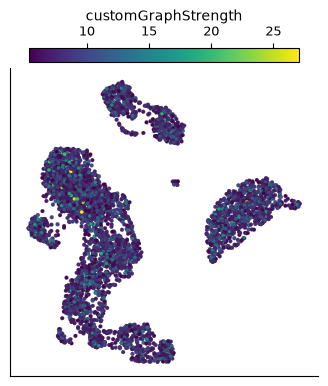

Started: 2026-10-08T11:03:26.784248Z | Wall time: 1.961 s

In [4]:
# Locate high and low graph connectivity on the saved embedding.
ds.plots.embedding(layout=run["umap"], color_by="customGraphStrength")

The plot asks where cells have stronger or weaker weighted connectivity in this specific graph.
Rebuilds with another feature set or neighbour count need a new statistic.

## Stream count blocks

A custom calculation can stay within a small memory budget by processing one count block at a
time. Avoid `.compute()` on a matrix that may exceed memory. Select the frozen run's cells and
highly variable genes before streaming, then keep only the small per-cell results from each block.
Here we count detected HVGs per active cell:

In [5]:
# Locate the run's cells on the stored count-matrix axis.
cell_index = np.flatnonzero(run.cells.fetch_all("I"))

# Read the run's highly variable gene selection.
hvg_values = np.asarray(run.features.fetch_all("highly_variable_features"), dtype=bool)

# Locate those genes on the stored feature axis.
feature_index = np.flatnonzero(hvg_values)

# Create a lazy view of the selected cells and genes.
selected_counts = ds.RNA.rawData[:, feature_index][cell_index, :]

# Check the selected matrix dimensions before streaming counts.
{"selected cells": len(cell_index), "selected genes": len(feature_index)}

{'selected cells': 3948, 'selected genes': 500}

Started: 2026-10-08T11:03:28.750980Z | Wall time: 0.460 s

Count detected genes one block at a time.

In [6]:
# Collect one small vector of detection counts per block.
detected_blocks = []

# Process a bounded count block without loading the full matrix.
for count_block in selected_counts.stream_blocks(
    nthreads=4, msg="Calculating custom detection statistic"
):

    # Keep this result in its original processing order.
    detected_blocks.append(np.count_nonzero(count_block, axis=1))

# Check how many cell results were collected across the blocks.
sum(len(block) for block in detected_blocks)

3948

Started: 2026-10-08T11:03:29.214111Z | Wall time: 0.802 s

Collect the per-cell results and save them in metadata.

In [7]:
# Join the block results in their original cell order.
detected_hvgs = np.concatenate(detected_blocks)

# Save the values in cell metadata using the stated selection.
ds.cells.insert(
    column_name="customDetectedHVGs", values=detected_hvgs, key="I", overwrite=True
)

# Summarize the per-cell detected-gene counts.
{
    "cells": int(detected_hvgs.size),
    "customDetectedHVGs mean": float(detected_hvgs.mean()),
    "customDetectedHVGs max": int(detected_hvgs.max()),
}

{'cells': 3948,
 'customDetectedHVGs mean': 123.48024316109422,
 'customDetectedHVGs max': 250}

Started: 2026-10-08T11:03:30.020046Z | Wall time: 0.092 s

`stream_blocks` preserves row order. Because active `I` is the frozen run selection, inserting with
that key keeps each streamed value aligned with its metadata row.
The summary checks that every streamed cell received a detection count.

## Create custom selections

A Boolean cell column can become a `cell_key`. Selecting cells this way does not delete their
counts: the selection controls which rows an operation reads, while the original store remains
available for a different selection later.
Use `fill_value=False` when the new key is defined only for currently active cells: the inactive
cells then hold `False`. Without it they are recorded as missing, which a key never selects either.
Here we keep cells above the lowest quarter of graph strength as an example of making a selection.
This is an illustration of the API, not a recommended quality-control filter:

In [8]:
# Keep cells above the lowest quarter of graph strength.
well_connected = graph_strength >= np.quantile(graph_strength, 0.25)

# Save the values in cell metadata using the stated selection.
ds.cells.insert(
    column_name="wellConnected",
    values=well_connected,
    fill_value=False,
    key="I",
    overwrite=True,
)

# Check how many active cells pass the custom selection.
{"selected cells": int(well_connected.sum()), "active cells": len(well_connected)}

{'selected cells': 2961, 'active cells': 3948}

Started: 2026-10-08T11:03:30.116976Z | Wall time: 0.041 s

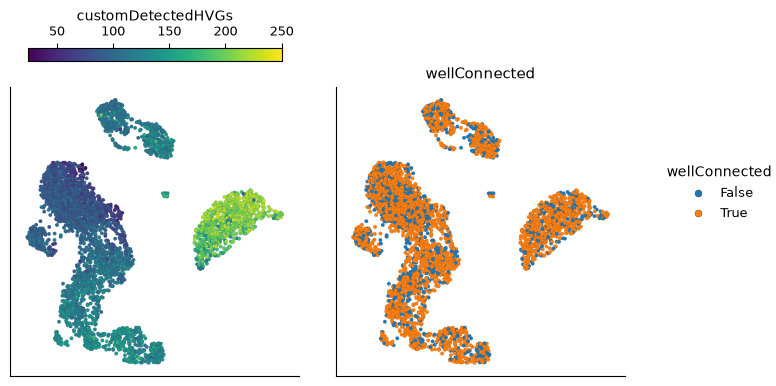

Started: 2026-10-08T11:03:30.162916Z | Wall time: 1.003 s

In [9]:
# Compare detected-gene counts and the custom cell selection.
ds.plots.embedding(
    layout=run["umap"], color_by=["customDetectedHVGs", "wellConnected"], n_columns=2
)

The first panel checks where the streamed count statistic varies.
The second shows the lower-quartile graph-strength exclusion created from the same active cell order.

## Pass a small selection to another tool

To pass a selection to a tool such as Scanpy, use `to_anndata`. It creates an in-memory AnnData
object, so select the cells and genes you need before materializing it. Here we export the custom
cell selection and a six-gene marker panel:

In [10]:
# Choose a small marker panel for the comparison.
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]

# Materialize only the selected cells and marker panel.
adata = ds.to_anndata(cell_key="wellConnected", feature_names=panel_genes)

# Check the exported dimensions and feature identifiers.
adata.shape, adata.var_names.tolist()

((2961, 6),
 ['ENSG00000167286',
  'ENSG00000156738',
  'ENSG00000170458',
  'ENSG00000090382',
  'ENSG00000105374',
  'ENSG00000115523'])

Started: 2026-10-08T11:03:31.169996Z | Wall time: 3.354 s

`to_anndata` drops unselected features.
It indexes `var` by gene ids (Ensembl here); gene symbols stay in `var["names"]`.
So `adata.var_names` after `feature_names=panel_genes` lists ids, not the panel symbols.
Check `adata.var["names"]` when you need the symbols.
Omit `feature_names` to include every feature, provided the resulting AnnData fits in memory.
See [](import_and_export.ipynb) for H5AD and Matrix Market export, and [](remote_stores.ipynb) when
the count source itself must remain remote.

## Write a selected CyteArc store

Use `SubsetZarr` when the next analysis should stay in CyteArc. It writes only the selected cells
while retaining every feature in the listed assays. This differs from the six-gene AnnData above:
the resulting store can support analyses using a new feature set.

In [11]:
# Create a temporary destination separate from the source store.
from pathlib import Path
from tempfile import TemporaryDirectory

export_directory = TemporaryDirectory()
subset_path = Path(export_directory.name) / "well_connected.zarr"

# Copy the chosen cells with all RNA genes and their existing filter flags.
writer = cytearc.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_key="wellConnected",
    reset_cell_filter=False,
)
writer.dump()

# Confirm the cell and gene counts in the independent subset.
subset = cytearc.DataStore(str(subset_path))
{"exported cells": subset.cells.N, "retained genes": subset.RNA.feats.N}

{'exported cells': 2961, 'retained genes': 33538}

Started: 2026-10-08T11:03:34.531642Z | Wall time: 7.380 s

Choose a persistent destination instead of `TemporaryDirectory` when you want to keep the subset
after the notebook session.

## Extension boundary

Direct arbitrary artifact writing is not a stable public extension API.
Do not mutate `ds.z`, `ds.zw`, `_matrix_z`, or other private storage attributes from analysis code.
Those objects expose implementation layout and can change as storage contracts evolve.

Use public metadata insertion, result-returning methods, graph loading, block streams, and export APIs.
Pipeline callbacks provide read-only execution events; their contract is documented in [Analysis pipeline API reference](/api/pipeline.html).